In [1]:
import numpy as np
import matplotlib.pyplot as plt

import config_1
import config_2

In [2]:
def make_label(config):
    label = (
        f"r_i = {config.R_FIRST:.3f}, "
        f"r_o = {config.R_OUTER:.1f}, "
        f"N_shell = {config.N_SHELL:d}, "
        f"DT_TOL = {config.DT_TOL:.4f}, "
        f"F_TOL = {config.F_TOL:.0e}, "
        f"F_ACCEPT = {config.F_ACCEPT:.0e}, "
        f"X_TOL = {config.X_TOL:.0e}")
    
    return label

In [3]:
labels = [make_label(config_1), make_label(config_2)]

In [4]:
data_1 = np.loadtxt("data/run_1/stats.txt")
data_2 = np.loadtxt("data/run_2/stats.txt")

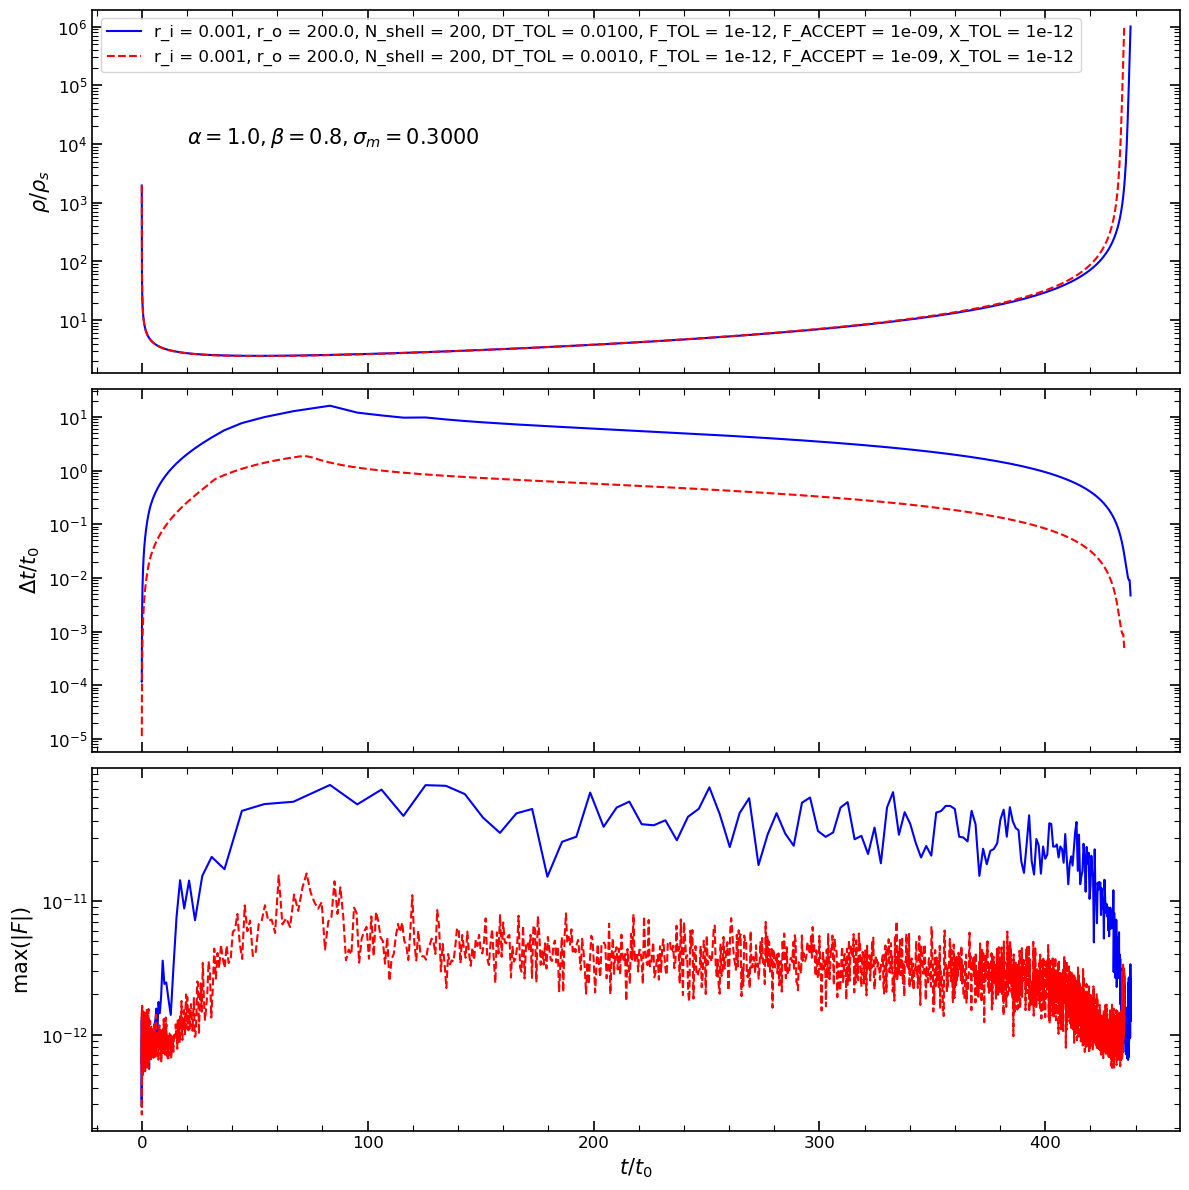

In [9]:
fig, ax = plt.subplots(3,1, figsize=(12,12), sharex='all')

ax[0].plot(data_1[:, 0], data_1[:, 5],color='blue',lw=1.5, label=labels[0])
ax[0].plot(data_2[:, 0], data_2[:, 5],color='red',lw=1.5,ls='--', label=labels[1])
ax[0].set_yscale("log")

ax[1].plot(data_1[:, 0], data_1[:, 1],color='blue',lw=1.5)
ax[1].plot(data_2[:, 0], data_2[:, 1],color='red',lw=1.5,ls='--')
ax[1].set_yscale("log")

ax[2].plot(data_1[:, 0], data_1[:, 3],color='blue',lw=1.5)
ax[2].plot(data_2[:, 0], data_2[:, 3],color='red',lw=1.5,ls='--')
ax[2].set_yscale("log")

for a in ax:
    for spine in a.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)

    a.tick_params(axis="both", which="major", direction="in", length=7, width=1.2, top=True, right=True, labelsize=12)
    a.tick_params(axis="both", which="minor", direction="in", length=4, width=0.8, top=True, right=True)

    a.set_yscale("log")
    a.minorticks_on()

ax[2].set_xlabel('$t/t_{0}$',fontsize=15)

ax[0].set_ylabel('$\\rho/\\rho_{s}$', fontsize=15)
ax[1].set_ylabel('$\\Delta t/t_{0}$', fontsize=15)
ax[2].set_ylabel('max($|F|$)', fontsize=15)

ax[0].legend(fontsize=12)

ax[0].text(20,1e4,'$\\alpha=%.1f, \\beta=%.1f, \sigma_{m}=%.4f$' 
           %(config_1.ALPHA, config_1.BETA, config_1.SIGMA_OVER_M), 
           fontsize=15) 


fig.tight_layout()
plt.savefig("plots/convergence_test.png", bbox_inches='tight')